<a href="https://colab.research.google.com/github/haiderimran019/gpt2-ioi-mechinterp/blob/main/01_ioi_head_sweep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformer_lens

  Using cached transformer_lens-4.0.0-py3-none-any.whl.metadata (14 kB)
Using cached transformer_lens-4.0.0-py3-none-any.whl (1.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 93.9 MB/s eta 0:00:00


In [ ]:
!pip install transformer_lens


In [ ]:
import transformer_lens
import torch

model = transformer_lens.TransformerBridge.boot_transformers("gpt2")
model.enable_compatibility_mode()

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [3]:
!pip install transformer_lens

import transformer_lens
import torch

model = transformer_lens.TransformerBridge.boot_transformers("gpt2")
model.enable_compatibility_mode()

prompt = "When John and Mary went to the store, John gave a drink to"

logits = model(prompt)  # the model's raw scores for every possible next word
last_token_logits = logits[0, -1]  # scores for the word AFTER the last token
top_tokens = last_token_logits.topk(5)

for score, token_id in zip(top_tokens.values, top_tokens.indices):
    print(f"{model.to_string(token_id)!r}  score: {score.item():.2f}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.9 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12526 sha256=8cd5bae16aa5033577d714487a9b6399a829e8fcab576d6da36896e8be655ccc
  Stored in directory: /root/.cache/pip/wheels/f6/6e/1a/710143d0e50e827ae5b60a47a6d43d715cf1c6e35881a05530
Successfully built transformers-stream-generator


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

' Mary'  score: 17.79
' them'  score: 16.95
' the'  score: 16.10
' his'  score: 15.05
' their'  score: 14.72


In [4]:
from importlib.metadata import version
print("transformer_lens:", version("transformer_lens"))
print("transformers:", version("transformers"))

prompt = "When John and Mary went to the store, John gave a drink to"
print(model.to_str_tokens(prompt))   # how the text is split into tokens

logits = model(prompt)
probs = logits[0, -1].softmax(dim=-1)
for name in [" Mary", " John", " water"]:
    tid = model.to_single_token(name)
    print(f"{name!r}: logit {logits[0, -1, tid].item():.2f}, prob {probs[tid].item():.4f}")

transformer_lens: 4.0.0
transformers: 5.16.1
['<|endoftext|>', 'When', ' John', ' and', ' Mary', ' went', ' to', ' the', ' store', ',', ' John', ' gave', ' a', ' drink', ' to']
' Mary': logit 17.79, prob 0.4807
' John': logit 14.62, prob 0.0201
' water': logit 6.92, prob 0.0000


In [5]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
hf_tok = GPT2TokenizerFast.from_pretrained("gpt2")
hf_model = GPT2LMHeadModel.from_pretrained("gpt2")
ids = hf_tok(prompt, return_tensors="pt").input_ids
hf_logits = hf_model(ids).logits[0, -1]
for score, tid in zip(hf_logits.topk(5).values, hf_logits.topk(5).indices):
    print(repr(hf_tok.decode(tid)), f"{score.item():.2f}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

' Mary' -75.24
' them' -75.80
' the' -76.58
' his' -77.75
' John' -77.77


In [6]:
bos_ids = torch.cat([torch.tensor([[hf_tok.bos_token_id]]), ids], dim=1)
hf_logits_bos = hf_model(bos_ids).logits[0, -1]

m = hf_tok.encode(" Mary")[0]
j = hf_tok.encode(" John")[0]
print("gap without start token:", (hf_logits[m] - hf_logits[j]).item())
print("gap with start token:   ", (hf_logits_bos[m] - hf_logits_bos[j]).item())

gap without start token: 2.5273895263671875
gap with start token:    3.172210693359375


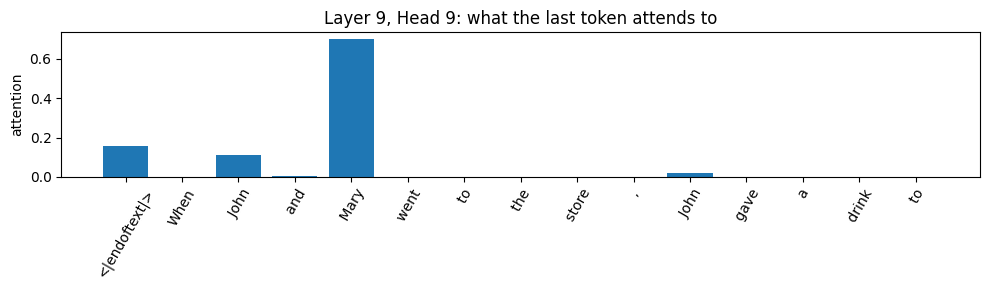

In [7]:
import matplotlib.pyplot as plt

prompt = "When John and Mary went to the store, John gave a drink to"
logits, cache = model.run_with_cache(prompt)

tokens = model.to_str_tokens(prompt)
attn = cache["pattern", 9][0, 9, -1]   # layer 9, head 9, from the LAST token, over all tokens

plt.figure(figsize=(10, 3))
plt.bar(range(len(tokens)), attn.detach().cpu())
plt.xticks(range(len(tokens)), tokens, rotation=60)
plt.ylabel("attention")
plt.title("Layer 9, Head 9: what the last token attends to")
plt.tight_layout()
plt.show()

In [10]:
import torch, random, numpy as np
import matplotlib.pyplot as plt
from importlib.metadata import version

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("transformer_lens", version("transformer_lens"), "| transformers", version("transformers"))

def single(word):
    return model.to_tokens(" " + word, prepend_bos=False).shape[1] == 1

names   = [n for n in ["John","Mary","Tom","James","Sarah","Anna","David","Emma","Mark","Lisa","Paul","Kate","Alex","Jack","Laura","Peter","Susan","Henry","Grace","Frank"] if single(n)]
places  = [p for p in ["store","park","school","office","garden","beach","market","station"] if single(p)]
objects = [o for o in ["drink","book","gift","letter","ball","coin","cake","note"] if single(o)]

N = 100
clean, corrupt, io_ids, s_ids = [], [], [], []
for _ in range(N):
    a, b, c = random.sample(names, 3)          # a = indirect object, b = subject, c = distractor
    p, o = random.choice(places), random.choice(objects)
    first, second = (a, b) if random.random() < 0.5 else (b, a)
    clean.append(  f"When {first} and {second} went to the {p}, {b} gave a {o} to")
    corrupt.append(f"When {first} and {second} went to the {p}, {c} gave a {o} to")
    io_ids.append(model.to_single_token(" " + a))
    s_ids.append(model.to_single_token(" " + b))

clean_tokens, corrupt_tokens = model.to_tokens(clean), model.to_tokens(corrupt)
assert clean_tokens.shape == corrupt_tokens.shape
io_ids, s_ids = torch.tensor(io_ids), torch.tensor(s_ids)
print(clean[0]); print(corrupt[0])

transformer_lens 4.0.0 | transformers 5.16.1
When Alex and Jack went to the garden, Jack gave a note to
When Alex and Jack went to the garden, Mary gave a note to


In [11]:
def logit_diff(logits):
    last = logits[:, -1, :]
    idx = torch.arange(len(last))
    return (last[idx, io_ids] - last[idx, s_ids]).mean().item()

with torch.no_grad():
    clean_logits = model(clean_tokens)
    corrupt_logits, corrupt_cache = model.run_with_cache(corrupt_tokens)

clean_ld, corrupt_ld = logit_diff(clean_logits), logit_diff(corrupt_logits)
last = clean_logits[:, -1, :]
acc = (last[torch.arange(N), io_ids] > last[torch.arange(N), s_ids]).float().mean().item()
print(f"clean logit diff: {clean_ld:.2f} | corrupted: {corrupt_ld:.2f} | accuracy (IO > S): {acc:.0%}")
print("example hook names:", [k for k in corrupt_cache.keys() if "hook_z" in k][:2])

clean logit diff: 3.60 | corrupted: -0.32 | accuracy (IO > S): 100%
example hook names: ['blocks.0.attn.hook_z', 'blocks.1.attn.hook_z']


In [ ]:
n_layers, n_heads = model.cfg.n_layers, model.cfg.n_heads

def sweep(mode):
    out = torch.zeros(n_layers, n_heads)
    def make_hook(head):
        def hook_fn(z, hook):
            if mode == "patch":
                z[:, :, head, :] = corrupt_cache[hook.name][:, :, head, :]
            else:
                z[:, :, head, :] = 0
            return z
        return hook_fn
    with torch.no_grad():
        for L in range(n_layers):
            for H in range(n_heads):
                lg = model.run_with_hooks(clean_tokens, fwd_hooks=[(f"blocks.{L}.attn.hook_z", make_hook(H))])
                out[L, H] = logit_diff(lg)
    return (clean_ld - out) / (clean_ld - corrupt_ld)   # 1.0 = this head alone accounts for the whole gap

patch_drop = sweep("patch")
zero_drop  = sweep("zero")
print("sweeps done")